# Descripción del problema

El siguiente ejemplo consiste en un Ambiente (Room). La temperatura de la habitación cambia debido a la temperatura externa ambiente (se asume de forma desconocida). La habitación cuenta con un equipo de Aire Acondicionado controlado por un Agente. El objetivo de este Agente es mantener la temperatura en 0 grados. El Aire Acondicionado puede cambiar la temperatura en 0, 1, 2 o 3 grados ya sea frío o calor.

# Ambiente

El ambiente (Room) está simulado por el siguiente código

In [1]:
from room import Room

# Test Room

In [2]:
env = Room()

In [3]:
env.observation_space

Box(-20.0, 40.0, (), float32)

In [4]:
env.observation_space.sample()

array(5.0486436, dtype=float32)

In [5]:
env.action_space

Discrete(7, start=-3)

In [6]:
env.action_space.sample()

np.int64(1)

In [7]:
env.reset()

np.float64(0.98)

# Reflex Agent

Esta es la implementación de un Agente Reflejo Simple, que dada la observación (temperatura de la habitación), toma una acción de enfriar o calentar en 0, 1, 2 o 3 grados. El agente solo enfría o calienta si la temperatura difiere en más de 2 grados.

In [8]:
from agent_reflex import AgentReflex

# Test Reflex

In [9]:
agent = AgentReflex(env)

In [10]:
obs = env.reset(seed=2)
print(f"Temperatura inicial de la sala: {obs}")
print(f"Temperatura externa (igual a la inicial después de un reset): {env.external_temp}")

Temperatura inicial de la sala: -8.34
Temperatura externa (igual a la inicial después de un reset): -8.34


In [11]:
# observamos el comportamiento del agente durante 100 pasos
total_steps = 100
# para almacenar las temperaturas externas y las observadas por el agente
external_res = []
agent_res = []


In [12]:
for i in range(0, total_steps):  
    
    # solamente para evaluar la evolución de la temperatura de la habitación con y sin agente
    # la temperatura de la habitación sin el agente es igual a la temperatura exterior
    
    external_temp = env.external_temp
    external_res.append(external_temp)
    
    # decisión y acción del agente
    
    prev_obs = obs
    action = agent.next_action(obs)
    obs = env.step(action)
    agent_res.append(obs)  
    
    print('Externa:', external_temp, '\n','Obs. anterior:', prev_obs, '-> Acción:', action, '-> Room:', obs)

Externa: -8.34 
 Obs. anterior: -8.34 -> Acción: 2 -> Room: -6.34
Externa: -8.34 
 Obs. anterior: -6.34 -> Acción: 2 -> Room: -2.49
Externa: -6.49 
 Obs. anterior: -2.49 -> Acción: 1 -> Room: 0.4299999999999997
Externa: -4.57 
 Obs. anterior: 0.4299999999999997 -> Acción: 0 -> Room: 2.4
Externa: -2.6 
 Obs. anterior: 2.4 -> Acción: -1 -> Room: 3.39
Externa: -0.6099999999999999 
 Obs. anterior: 3.39 -> Acción: -1 -> Room: 4.39
Externa: 1.39 
 Obs. anterior: 4.39 -> Acción: -1 -> Room: 5.38
Externa: 3.38 
 Obs. anterior: 5.38 -> Acción: -2 -> Room: 5.33
Externa: 5.33 
 Obs. anterior: 5.33 -> Acción: -2 -> Room: 5.23
Externa: 7.23 
 Obs. anterior: 5.23 -> Acción: -2 -> Room: 5.050000000000001
Externa: 9.05 
 Obs. anterior: 5.050000000000001 -> Acción: -2 -> Room: 4.789999999999999
Externa: 10.79 
 Obs. anterior: 4.789999999999999 -> Acción: -1 -> Room: 5.41
Externa: 12.41 
 Obs. anterior: 5.41 -> Acción: -2 -> Room: 4.92
Externa: 13.92 
 Obs. anterior: 4.92 -> Acción: -1 -> Room: 5.279999

# Métrica de Performance
Una posible métrica de performance, podría ser la temperatura media del ambiente con la acción del agente.

In [13]:
import numpy as np
print("Temperatura media con el agente: ", np.mean(agent_res))
print("Temperatura media sin el agente: ", np.mean(external_res))

Temperatura media con el agente:  0.2663999999999993
Temperatura media sin el agente:  3.6919999999999997


# Graficando los resultados

In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error


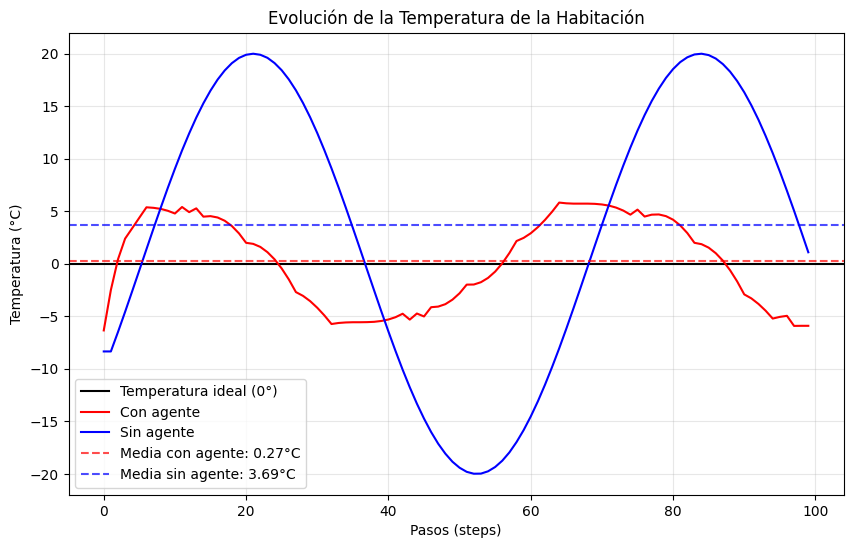

In [15]:
# Calcular temperaturas medias
mean_agent_temp = np.mean(agent_res)
mean_external_temp = np.mean(external_res)

plt.figure(figsize=(10, 6))
plt.axhline(color='black', label='Temperatura ideal (0°)')    #Temperatura ideal
plt.plot(range(0, total_steps), agent_res, color='red', label='Con agente')     #Temperatura con el agente
plt.plot(range(0, total_steps), external_res, color='blue', label='Sin agente') #Temperatura sin agente

# Agregar líneas horizontales con las temperaturas medias
plt.axhline(y=mean_agent_temp, color='red', linestyle='--', alpha=0.7, 
            label=f'Media con agente: {mean_agent_temp:.2f}°C')
plt.axhline(y=mean_external_temp, color='blue', linestyle='--', alpha=0.7, 
            label=f'Media sin agente: {mean_external_temp:.2f}°C')

plt.title('Evolución de la Temperatura de la Habitación')
plt.xlabel('Pasos (steps)')
plt.ylabel('Temperatura (°C)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Otra posible métrica de performance, es evaluar para cada instante de tiempo (step) cuanto difiere la temperatura obtenida de la objetivo=0. Esto se puede hacer con mean_squared_error o mean_absolute_error. 
Comparemos la métrica obtenida por el agente contra la métrica obtenida sin un agente:

In [16]:
goal_temp = np.zeros(total_steps)
print("Variación media con el agente: ", mean_absolute_error(goal_temp, agent_res))
print("Variación media sin el agente: ", mean_absolute_error(goal_temp, external_res))

Variación media con el agente:  3.8579999999999997
Variación media sin el agente:  12.310399999999998


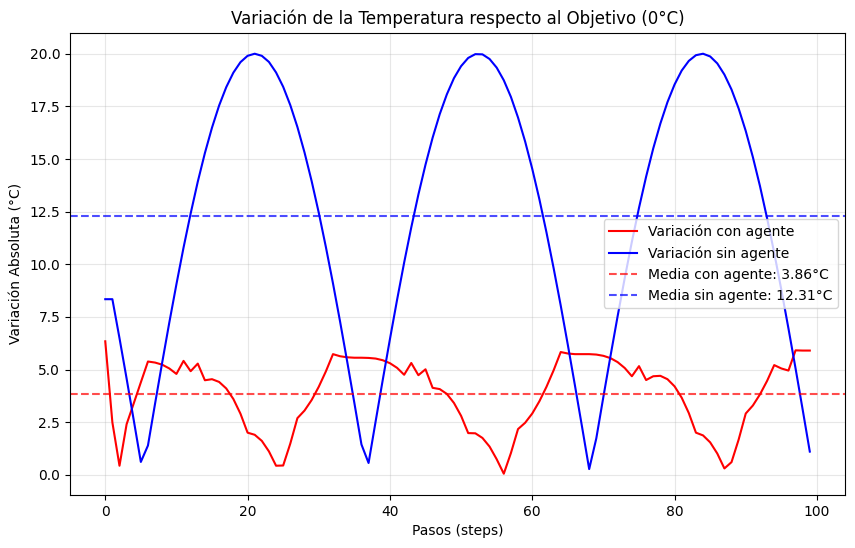

In [17]:
# Calcular la variación (diferencia absoluta respecto al objetivo) en cada paso
agent_variation = np.abs(np.array(agent_res) - 0)
external_variation = np.abs(np.array(external_res) - 0)

# Calcular las variaciones medias
mean_agent_variation = mean_absolute_error(goal_temp, agent_res)
mean_external_variation = mean_absolute_error(goal_temp, external_res)

# Graficar la variación
plt.figure(figsize=(10, 6))
plt.plot(range(0, total_steps), agent_variation, color='red', label='Variación con agente')
plt.plot(range(0, total_steps), external_variation, color='blue', label='Variación sin agente')

# Agregar líneas horizontales con las variaciones medias
plt.axhline(y=mean_agent_variation, color='red', linestyle='--', alpha=0.7, 
            label=f'Media con agente: {mean_agent_variation:.2f}°C')
plt.axhline(y=mean_external_variation, color='blue', linestyle='--', alpha=0.7, 
            label=f'Media sin agente: {mean_external_variation:.2f}°C')

plt.title('Variación de la Temperatura respecto al Objetivo (0°C)')
plt.xlabel('Pasos (steps)')
plt.ylabel('Variación Absoluta (°C)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Ejercicio: Model (Goal / Utility) Based Agent 

Construir un Agente basado en un modelo. 
Esto es: 
    - Construir un modelo a mano, por ejemplo un grafo, con estados y transiciones [Ver figura].
    - Discretizar las observaciones devueltas por el ambiente mapeándolas a un estado.
    - Tomar una decisón basada en el estado.
    - Definir un objetivo y una utilidad

Por ejemplo, el Agente podría conocer un modelo que tiene 2 estados {Frío, Calor}
<img src="Modelo.png">
